# <div style="background: linear-gradient(90deg, #0f172a, #7c2d12); padding: 16px 20px; border-radius: 12px; color: white;">
# CIC IIoT Dataset 2025: Benign vs Attack Comparison
# </div>

<div style="margin-top: 12px; padding: 14px 18px; border-left: 6px solid #1d4ed8; background: #eff6ff; border-radius: 8px;">
<b>Research question:</b> Does using a knowledge graph with a graph neural network (GNN) detect attacks on IoT better than using normal models that do not use graphs?<br>
<b>Purpose of this notebook:</b> compare benign and attack traffic directly so we can identify the variables, patterns, and trade-offs that are most promising for later classification and graph-based modeling.
</div>

## Why this notebook is important

The benign notebook showed us what normal traffic looks like. The attack notebook showed us what malicious traffic looks like. This combined notebook is where the real comparison begins.

This is the notebook that starts answering the research question because here we can:

- compare benign and attack traffic side by side,
- identify the variables that change the most,
- examine whether the classes are balanced or highly imbalanced,
- prepare the data for future classical models and graph-based models.


## <div style="color:#1d4ed8;">0. Technical glossary for this dataset</div>

This section defines the main network and cybersecurity terms used in this project. The goal is to make the exploratory analysis, classification models, graph analysis, and GNN results easier to explain in the paper and presentation.

The definitions below are written in simple research language, but they are based on technical references from NIST CSRC, CISA, Cloudflare, OWASP, and MITRE ATT&CK.

### A. Network traffic concepts

| Term | Meaning in this project | Why it matters for intrusion detection |
|---|---|---|
| **1-second window** | One row in the dataset. It summarizes the traffic observed during one second. | The model is not classifying one raw packet; it is classifying a short time summary of activity. |
| **Network traffic** | The movement of packets between devices, IPs, ports, and services. | Attacks often change traffic volume, direction, protocol use, and connection behavior. |
| **Packet** | A small unit of network communication. Larger messages are divided into packets before being transmitted. | Packet counts and packet sizes help identify bursts, floods, scans, or abnormal communication. |
| **Header** | The control information attached to a packet, such as source/destination IPs, ports, protocol, flags, and routing information. | Some attacks may be visible mainly through header behavior, even when payload length is low or zero. |
| **Payload** | The actual content/data carried by the packet after the header. | Payload length helps distinguish empty/control traffic from data-carrying traffic. |
| **Payload length** | The size of the packet's carried data. | Low payload length with high packet count can suggest scanning, control signaling, or flood-like behavior. |
| **IP address** | A numerical identifier for a device or endpoint on a network. | Counts of source/destination IPs help measure how many endpoints are involved in a window. |
| **Port** | A logical endpoint used by a device to separate services or applications. | High port diversity can suggest scanning or attacks against multiple services. |
| **Protocol** | A standardized rule set that determines how devices format, send, and interpret network data. | Protocol changes help identify whether traffic is TCP-based, UDP-based, ICMP-based, etc. |
| **Source (`src`)** | The origin side of the communication. | Source counts show where traffic is coming from. |
| **Destination (`dst`)** | The receiving side of the communication. | Destination counts show what devices, ports, or services are being targeted. |
| **TTL / Time to Live** | A packet field that limits how long a packet can travel through the network before being discarded. | Unusual TTL patterns can indicate different routing paths, spoofing, or traffic generated by different tools/devices. |

### B. Protocols and TCP flags

| Term | Full name | Meaning in this project | Interpretation |
|---|---|---|---|
| **TCP** | Transmission Control Protocol | A connection-oriented transport protocol that establishes a reliable connection between hosts. | TCP features are important when attacks involve connections, handshakes, acknowledgments, or TCP flag abuse. |
| **UDP** | User Datagram Protocol | A connectionless transport protocol that sends datagrams without establishing a reliable session first. | UDP is often used in fast traffic bursts or flood attacks because it has less connection overhead than TCP. |
| **ICMP** | Internet Control Message Protocol | A protocol used for network diagnostics and control messages, such as ping. | ICMP activity can appear in ping sweeps, host discovery, and ICMP flood attacks. |
| **ARP** | Address Resolution Protocol | A local-network protocol that maps IP addresses to hardware/MAC addresses. | ARP behavior is important for ARP spoofing and local man-in-the-middle behavior. |
| **MQTT** | Message Queuing Telemetry Transport | A lightweight publish/subscribe protocol often used in IoT communication. | Since this is an IIoT dataset, MQTT-related ports or devices can be important attack targets. |
| **ACK** | Acknowledgment flag | A TCP flag used to acknowledge received packets. | High ACK activity can indicate normal TCP communication, but abnormal ACK patterns may appear in ACK floods or scans. |
| **SYN** | Synchronize flag | A TCP flag used to start a connection. | High SYN activity can indicate connection attempts, SYN scans, or SYN flood behavior. |
| **FIN** | Finish flag | A TCP flag used to close a connection. | Abnormal FIN patterns can appear in stealth scans or flood variants. |
| **RST** | Reset flag | A TCP flag used to abruptly reset a connection. | High RST activity can indicate failed connections, scans, or attack-generated traffic. |
| **PSH / PUSH** | Push flag | A TCP flag that asks the receiver to pass data quickly to the application. | PUSH-ACK patterns can appear in specific TCP flood variants. |

### C. General attack categories in the attack dataset

| Dataset label | Meaning | How to interpret it in this dataset |
|---|---|---|
| **DoS** | Denial of Service. A single source or smaller attack setup attempts to make a service unavailable. | Often visible as high traffic volume or repeated requests toward a target. |
| **DDoS** | Distributed Denial of Service. Multiple systems coordinate traffic against the same target. | Can appear as high packet counts, many sources, repeated ports, or flood-like patterns. |
| **MITM** | Man-in-the-Middle. An attacker positions themselves between communicating parties to intercept or alter traffic. | In this dataset, MITM includes examples such as ARP spoofing and IP spoofing. |
| **Malware** | Malicious software or code intended to compromise confidentiality, integrity, or availability. | In this dataset, malware includes Mirai-style IoT flood behavior. |
| **Web attack** | An attack against a web application or web-facing service. | In this dataset, examples include SQL injection and command injection. |
| **Bruteforce** | Repeated trial-and-error attempts to guess credentials or discover valid access. | In this dataset, dictionary attacks against SSH or Telnet are examples. |
| **Reconnaissance** | Activity where an adversary gathers information before or during an attack. | Includes scans that discover hosts, ports, operating systems, or vulnerabilities. |

### D. Specific attack names that appear in this dataset

| Attack name | Meaning | Expected traffic pattern |
|---|---|---|
| **ARP spoofing** | A MITM technique where ARP messages are abused so traffic is redirected through the attacker. | Can create abnormal ARP/local-network behavior and altered source-destination relationships. |
| **IP spoofing** | A technique where traffic is sent with a falsified source IP address. | Can make source identity unreliable and may change IP-count or TTL patterns. |
| **Mirai UDP flood** | Mirai-style malware generates high-volume UDP traffic. | Usually high packet counts, UDP protocol activity, and possible repeated target ports. |
| **Mirai SYN flood** | Mirai-style malware generates many TCP SYN packets. | High SYN activity and many connection attempts without normal completion. |
| **UDP flood** | Large volume of UDP packets sent to overwhelm a target. | High UDP packet count, sometimes low payload or repeated destinations. |
| **TCP flood** | Large volume of TCP traffic sent to overwhelm a target. | High TCP packet count and possibly abnormal flag combinations. |
| **ICMP flood** | Large volume of ICMP traffic, often ping-like traffic, sent to overwhelm a target. | High ICMP activity and packet bursts. |
| **SYN flood** | Many TCP SYN packets sent to exhaust connection resources. | High SYN count, many incomplete connection attempts. |
| **ACK flood** | Many TCP ACK packets sent to overwhelm a target or network device. | High ACK count and unusual acknowledgment traffic. |
| **RST-FIN flood** | Flood traffic using TCP reset and finish flags. | Abnormal RST/FIN flag activity. |
| **PUSH-ACK flood** | Flood traffic using TCP PUSH and ACK behavior. | Abnormal PSH/ACK flag activity. |
| **UDP fragmentation flood** | UDP traffic is fragmented to stress reassembly or filtering mechanisms. | Fragment-related packet patterns and high UDP traffic. |
| **ICMP fragmentation flood** | ICMP traffic is fragmented to stress target processing. | Fragment-related ICMP activity. |
| **Port scan** | A recon technique that checks which ports/services are open. | Increased destination-port diversity. |
| **OS scan** | A recon technique that attempts to infer the target operating system. | Multiple probes and response patterns against a host. |
| **Vulnerability scan** | A recon technique that checks whether a host or service may have exploitable weaknesses. | Repeated probes across services or known vulnerable endpoints. |
| **Ping sweep** | A recon technique that sends ping-like probes to identify active hosts. | ICMP or host-discovery patterns across many IPs. |
| **Host discovery** | A recon technique used to identify which devices are alive on the network. | Increased IP activity and probe-like traffic. |
| **SQL injection** | A web attack where malicious SQL is sent through application inputs. | More likely visible in web/service traffic than in simple packet counts alone. |
| **Command injection** | A web attack where malicious system commands are sent through application inputs. | May be visible through web traffic patterns and target service behavior. |
| **Dictionary SSH/Telnet attack** | A bruteforce attack using a list of possible credentials. | Repeated login attempts against SSH or Telnet-related services. |

### E. Sources used for these definitions

- NIST CSRC Glossary: [TCP](https://csrc.nist.gov/glossary/term/TCP), [UDP](https://csrc.nist.gov/glossary/term/udp), [Packet](https://csrc.nist.gov/glossary/term/packet), [MITM](https://csrc.nist.gov/glossary/term/man_in_the_middle_attack), [Malware](https://csrc.nist.gov/glossary/term/malware), and [Attack](https://csrc.nist.gov/glossary/term/attack).
- CISA: [Understanding Denial-of-Service Attacks](https://www.cisa.gov/news-events/news/understanding-denial-service-attacks) and [Malware, Phishing, and Ransomware](https://www.cisa.gov/topics/cyber-threats-and-advisories/malware-phishing-and-ransomware).
- Cloudflare Learning Center: [Network packets](https://www.cloudflare.com/learning/network-layer/what-is-a-packet/), [Internet Protocol](https://www.cloudflare.com/learning/network-layer/internet-protocol/), [Network ports](https://www.cloudflare.com/learning/network-layer/what-is-a-computer-port/), and [ACK flood / ACK packets](https://www.cloudflare.com/en-gb/learning/ddos/what-is-an-ack-flood/).
- OWASP: [Brute Force Attack](https://owasp.org/www-community/attacks/Brute_force_attack) and [OWASP Attacks](https://owasp.org/www-community/attacks/).
- MITRE ATT&CK: [Reconnaissance tactic](https://attack.mitre.org/tactics/TA0043/) and [Enterprise tactics](https://attack.mitre.org/tactics/enterprise/).


In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 120)
pd.set_option('display.max_rows', 200)
plt.style.use('ggplot')

BASE_PATH = Path(r"/Users/hectorcas13/Library/CloudStorage/Dropbox/Universidad/PhD-Albany/CINF897-Independent_Study&Resarch")
BENIGN_PATH = BASE_PATH / 'IoT_dataset' / 'CIC IIoT dataset 2025' / 'Benign_data' / 'benign_samples_1sec.csv'
ATTACK_PATH = BASE_PATH / 'IoT_dataset' / 'CIC IIoT dataset 2025' / 'Attack_samples' / 'attack_samples_1sec.csv'

BENIGN_PATH, ATTACK_PATH


(PosixPath('/Users/hectorcas13/Library/CloudStorage/Dropbox/Universidad/PhD-Albany/CINF897-Independent_Study&Resarch/IoT_dataset/CIC IIoT dataset 2025/Benign_data/benign_samples_1sec.csv'),
 PosixPath('/Users/hectorcas13/Library/CloudStorage/Dropbox/Universidad/PhD-Albany/CINF897-Independent_Study&Resarch/IoT_dataset/CIC IIoT dataset 2025/Attack_samples/attack_samples_1sec.csv'))

## <div style="color:#1d4ed8;">1. Load both datasets</div>

We load both files and create a shared class column named `dataset_class`. This new column is useful because it gives us a simple binary label for comparison: `benign` or `attack`.


In [2]:
benign_df = pd.read_csv(BENIGN_PATH)
attack_df = pd.read_csv(ATTACK_PATH)

for frame in [benign_df, attack_df]:
    frame['timestamp_start'] = pd.to_datetime(frame['timestamp_start'], utc=True)
    frame['timestamp_end'] = pd.to_datetime(frame['timestamp_end'], utc=True)

benign_df['dataset_class'] = 'benign'
attack_df['dataset_class'] = 'attack'

combined_df = pd.concat([benign_df, attack_df], ignore_index=True)

print('Benign shape:', benign_df.shape)
print('Attack shape:', attack_df.shape)
print('Combined shape:', combined_df.shape)


Benign shape: (136800, 95)
Attack shape: (90391, 95)
Combined shape: (227191, 95)


## <div style="color:#1d4ed8;">2. Are the datasets compatible?</div>

Before comparing them, we need to confirm that both files have the same structure. If the columns differ, then comparison and modeling would be unreliable.


In [3]:
same_columns = list(benign_df.columns[:-1]) == list(attack_df.columns[:-1])
compatibility = pd.DataFrame({
    'Check': ['Same number of original columns', 'Same original column order', 'Combined rows', 'Combined columns'],
    'Value': [benign_df.shape[1] - 1 == attack_df.shape[1] - 1, same_columns, combined_df.shape[0], combined_df.shape[1]]
})
compatibility


,Check,Value
0,Same number of original columns,True
1,Same original column order,True
2,Combined rows,227191
3,Combined columns,95


### Interpretation

This is good news: the benign and attack files share the same original structure, so we can compare them directly. That means any major differences we find are more likely to reflect traffic behavior rather than schema mismatch.


## <div style="color:#1d4ed8;">3. Class balance and dataset scope</div>

One of the first things we must inspect is class balance. In intrusion detection, imbalance is common, but extreme imbalance can distort evaluation and model training.


In [4]:
class_counts = combined_df['dataset_class'].value_counts()
class_pct = (combined_df['dataset_class'].value_counts(normalize=True) * 100).round(3)

class_summary = pd.DataFrame({
    'count': class_counts,
    'percentage': class_pct
})
class_summary


,count,percentage
dataset_class,,
benign,136800,60.214
attack,90391,39.786


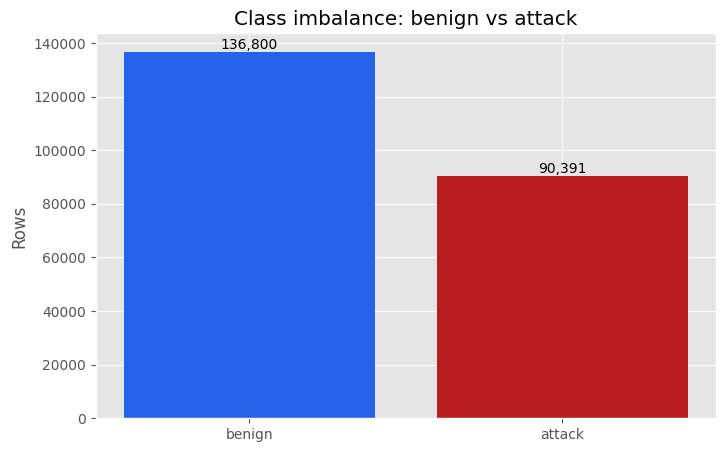

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(class_summary.index, class_summary['count'], color=['#2563eb', '#b91c1c'])
ax.set_title('Class imbalance: benign vs attack')
ax.set_ylabel('Rows')
for i, value in enumerate(class_summary['count']):
    ax.text(i, value, f'{value:,}', ha='center', va='bottom')
plt.show()


### Interpretation

<div style="padding: 12px 16px; background: #fef2f2; border-radius: 8px; border: 1px solid #fca5a5;">
The combined data is still imbalanced, but it is much more manageable now: benign traffic remains the majority, yet attack traffic is large enough to support meaningful supervised comparison.
</div>

Why this matters:

- A model could get very high accuracy simply by predicting `benign` most of the time.
- Accuracy alone will be misleading in this project.
- Later we will need metrics like precision, recall, F1-score, ROC-AUC, and confusion matrices.
- We may also need class weighting, resampling, or device-aware evaluation.


## <div style="color:#1d4ed8;">4. Which devices appear in both datasets?</div>

This comparison is important because if attack traffic appears on totally different devices than benign traffic, then a model might learn device identity instead of attack behavior.


In [6]:
overlap_devices = sorted(set(benign_df['device_name']).intersection(set(attack_df['device_name'])))
device_overlap_summary = pd.DataFrame({
    'Metric': ['Benign unique devices', 'Attack unique devices', 'Overlapping devices'],
    'Value': [benign_df['device_name'].nunique(), attack_df['device_name'].nunique(), len(overlap_devices)]
})
device_overlap_summary


,Metric,Value
0,Benign unique devices,38
1,Attack unique devices,38
2,Overlapping devices,38


In [7]:
print('Overlapping devices:', overlap_devices)
print('\nBenign rows for overlapping devices:')
print(benign_df[benign_df['device_name'].isin(overlap_devices)]['device_name'].value_counts().to_string())
print('\nAttack rows by device:')
print(attack_df['device_name'].value_counts().to_string())


Overlapping devices: ['accelerometer-sensor', 'ap', 'blurams-camera', 'dekco-camera', 'edge1', 'flame-sensor', 'gas-sensor', 'geeni-camera', 'light-sensor', 'motion-sensor', 'mqtt-broker', 'myq-camera', 'plug-all-cameras', 'plug-all-rpb', 'plug-all-sensors', 'plug-cameras-dekco-blurams', 'plug-cameras-geeni', 'plug-cameras-yi', 'plug-edge1', 'plug-flame', 'plug-motion', 'plug-mqtt', 'plug-proximity', 'plug-rfid', 'plug-vibration', 'proximity-collision-sensor', 'rfid-sensor', 'router', 'soil-sensor', 'sound-sensor', 'steam-sensor', 'switch', 'ultrasonic-sensor', 'vibration-sensor', 'water-sensor', 'weather-sensor', 'wisenet-camera', 'yi-camera']

Benign rows for overlapping devices:
device_name
router                        3600
mqtt-broker                   3600
edge1                         3600
switch                        3600
ap                            3600
weather-sensor                3600
water-sensor                  3600
soil-sensor                   3600
steam-sensor     

### Interpretation

This is encouraging: many attack devices also exist in the benign dataset. That means later we can compare normal versus attack behavior for overlapping device families, which is much more meaningful than comparing completely different devices.

That overlap strengthens the study because it lets us ask whether the same device behaves differently under benign and attack conditions. At the same time, we should still be careful about generalization, because the attack data may not cover every device in the benign environment equally.


## <div style="color:#1d4ed8;">5. Key traffic variables to compare</div>

The following variables are especially useful because they summarize traffic volume, diversity, size, timing, and packet behavior in a compact way.

### What these variables mean

- **`network_packets_all_count`**: total packets in the 1-second window. This is a strong indicator of traffic intensity.
- **`network_packets_src_count`**: packets sent from the source side. This helps capture outgoing intensity.
- **`network_packets_dst_count`**: packets received on the destination side. This helps capture incoming intensity.
- **`network_ips_all_count`**: number of unique IPs in the window. This measures communication breadth.
- **`network_ports_all_count`**: number of unique ports observed. This helps reveal whether communication is narrow or widely spread across services.
- **`network_protocols_all_count`**: number of unique protocols. This reflects how diverse the communication stack is in each window.
- **`network_packet-size_avg`**: average packet size. This helps distinguish small repetitive packets from larger data transfer.
- **`network_payload-length_avg`**: average payload length. This is useful because some attacks generate many packets with little real payload.
- **`network_ttl_avg`**: average TTL. This can reflect routing or path consistency.
- **`network_time-delta_avg`**: average time between packets. Very small values often indicate tightly packed traffic.


In [8]:
key_features = [
    'network_packets_all_count',
    'network_packets_src_count',
    'network_packets_dst_count',
    'network_ips_all_count',
    'network_ports_all_count',
    'network_protocols_all_count',
    'network_packet-size_avg',
    'network_payload-length_avg',
    'network_ttl_avg',
    'network_time-delta_avg'
]

comparison_summary = pd.DataFrame({
    'benign_mean': benign_df[key_features].mean(),
    'attack_mean': attack_df[key_features].mean(),
    'benign_median': benign_df[key_features].median(),
    'attack_median': attack_df[key_features].median()
})
comparison_summary['attack_mean_over_benign_mean'] = comparison_summary['attack_mean'] / comparison_summary['benign_mean'].replace(0, pd.NA)
comparison_summary


,benign_mean,attack_mean,benign_median,attack_median,attack_mean_over_benign_mean
network_packets_all_count,2.976594,18029.761945,0.0,202.000000,6057.179638
network_packets_src_count,1.565161,1181.193614,0.0,18.000000,754.678753
network_packets_dst_count,1.411433,16848.568331,0.0,80.000000,11937.209441
network_ips_all_count,1.403487,8.872598,0.0,2.000000,6.321825
network_ports_all_count,1.162149,6060.964532,0.0,26.000000,5215.307066
network_protocols_all_count,0.938604,2.003595,0.0,2.000000,2.134655
network_packet-size_avg,60.348485,170.980627,0.0,60.034320,2.833222
network_payload-length_avg,34.677898,169.905808,0.0,0.082192,4.899542
network_ttl_avg,64.743926,83.046881,0.0,64.004252,1.282698
network_time-delta_avg,0.009258,0.003359,0.0,0.000106,0.362785


### Interpretation

This table is one of the most important parts of the notebook because it shows where attack traffic separates most clearly from benign traffic.

Main takeaways:

- Attack windows have dramatically larger packet counts than benign windows.
- Attack windows also show extremely large port counts, which may indicate broad service-level activity or highly repetitive port-level flooding.
- Average packet size does not change as dramatically as packet volume. This means intensity may be a stronger signal than packet size.
- Average payload length is actually lower in attack traffic than in benign traffic, which suggests the malicious traffic may be heavy in transport behavior but not rich in useful content.
- Average time delta is much smaller in attack traffic, meaning the packets arrive much more tightly packed in time.

This is exactly the kind of comparison that helps us choose features for classical models and also decide what relationships must be preserved in a graph.


## <div style="color:#1d4ed8;">6. Which numeric features differ the most?</div>

This section ranks numeric variables by the absolute difference between benign and attack means. It helps us identify the strongest candidate features for later modeling.


In [9]:
numeric_cols = benign_df.select_dtypes(include='number').columns
feature_diff_rows = []
for col in numeric_cols:
    feature_diff_rows.append({
        'feature': col,
        'benign_mean': benign_df[col].mean(),
        'attack_mean': attack_df[col].mean(),
        'benign_median': benign_df[col].median(),
        'attack_median': attack_df[col].median()
    })

feature_diff_df = pd.DataFrame(feature_diff_rows)
feature_diff_df['mean_abs_diff'] = (feature_diff_df['attack_mean'] - feature_diff_df['benign_mean']).abs()
top_feature_diff = feature_diff_df.sort_values('mean_abs_diff', ascending=False).head(15)
top_feature_diff


,feature,benign_mean,attack_mean,benign_median,attack_median,mean_abs_diff
36,network_packets_all_count,2.976594,18029.761945,0.0,202.000000,18026.785352
37,network_packets_dst_count,1.411433,16848.568331,0.0,80.000000,16847.156898
68,network_window-size_max,18985.302478,26662.266564,0.0,5744.000000,7676.964086
43,network_ports_all_count,1.162149,6060.964532,0.0,26.000000,6059.802383
45,network_ports_src_count,1.075541,5631.505648,0.0,23.000000,5630.430107
52,network_tcp-flags-rst_count,0.001762,3399.648560,0.0,0.000000,3399.646798
49,network_tcp-flags-ack_count,2.280402,3013.368698,0.0,16.000000,3011.088296
50,network_tcp-flags-fin_count,0.005022,2819.782036,0.0,0.000000,2819.777014
53,network_tcp-flags-syn_count,0.006148,2599.482968,0.0,0.000000,2599.476821
51,network_tcp-flags-psh_count,1.082522,1965.898972,0.0,0.000000,1964.816450


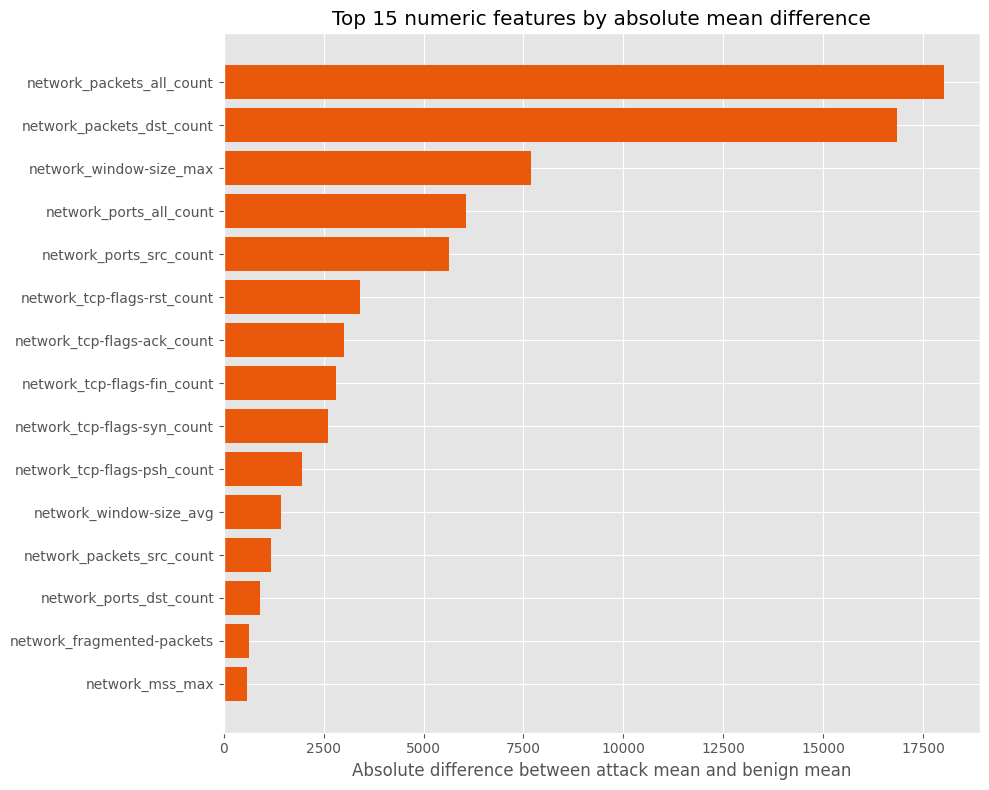

In [10]:
plot_df = top_feature_diff.sort_values('mean_abs_diff')
fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(plot_df['feature'], plot_df['mean_abs_diff'], color='#ea580c')
ax.set_title('Top 15 numeric features by absolute mean difference')
ax.set_xlabel('Absolute difference between attack mean and benign mean')
plt.tight_layout()
plt.show()


### Interpretation

The strongest separating variables are mostly related to:

- packet counts,
- port counts,
- TCP flag counts,
- and some transport/window statistics.

That tells us something important: for this particular attack sample, the difference between normal and malicious traffic is driven more by intensity and transport behavior than by rich application payload.

This also suggests a future modeling strategy:

- classical models can start with these numeric features,
- graph models should preserve communication structure, ports, and protocol interactions because those appear behaviorally important.


## <div style="color:#1d4ed8;">7. Visual comparison of key distributions</div>

The next plots compare benign and attack distributions directly. Because the class imbalance is extreme, we use a balanced sample for visualization so the attack distribution is not visually drowned out by the benign class.


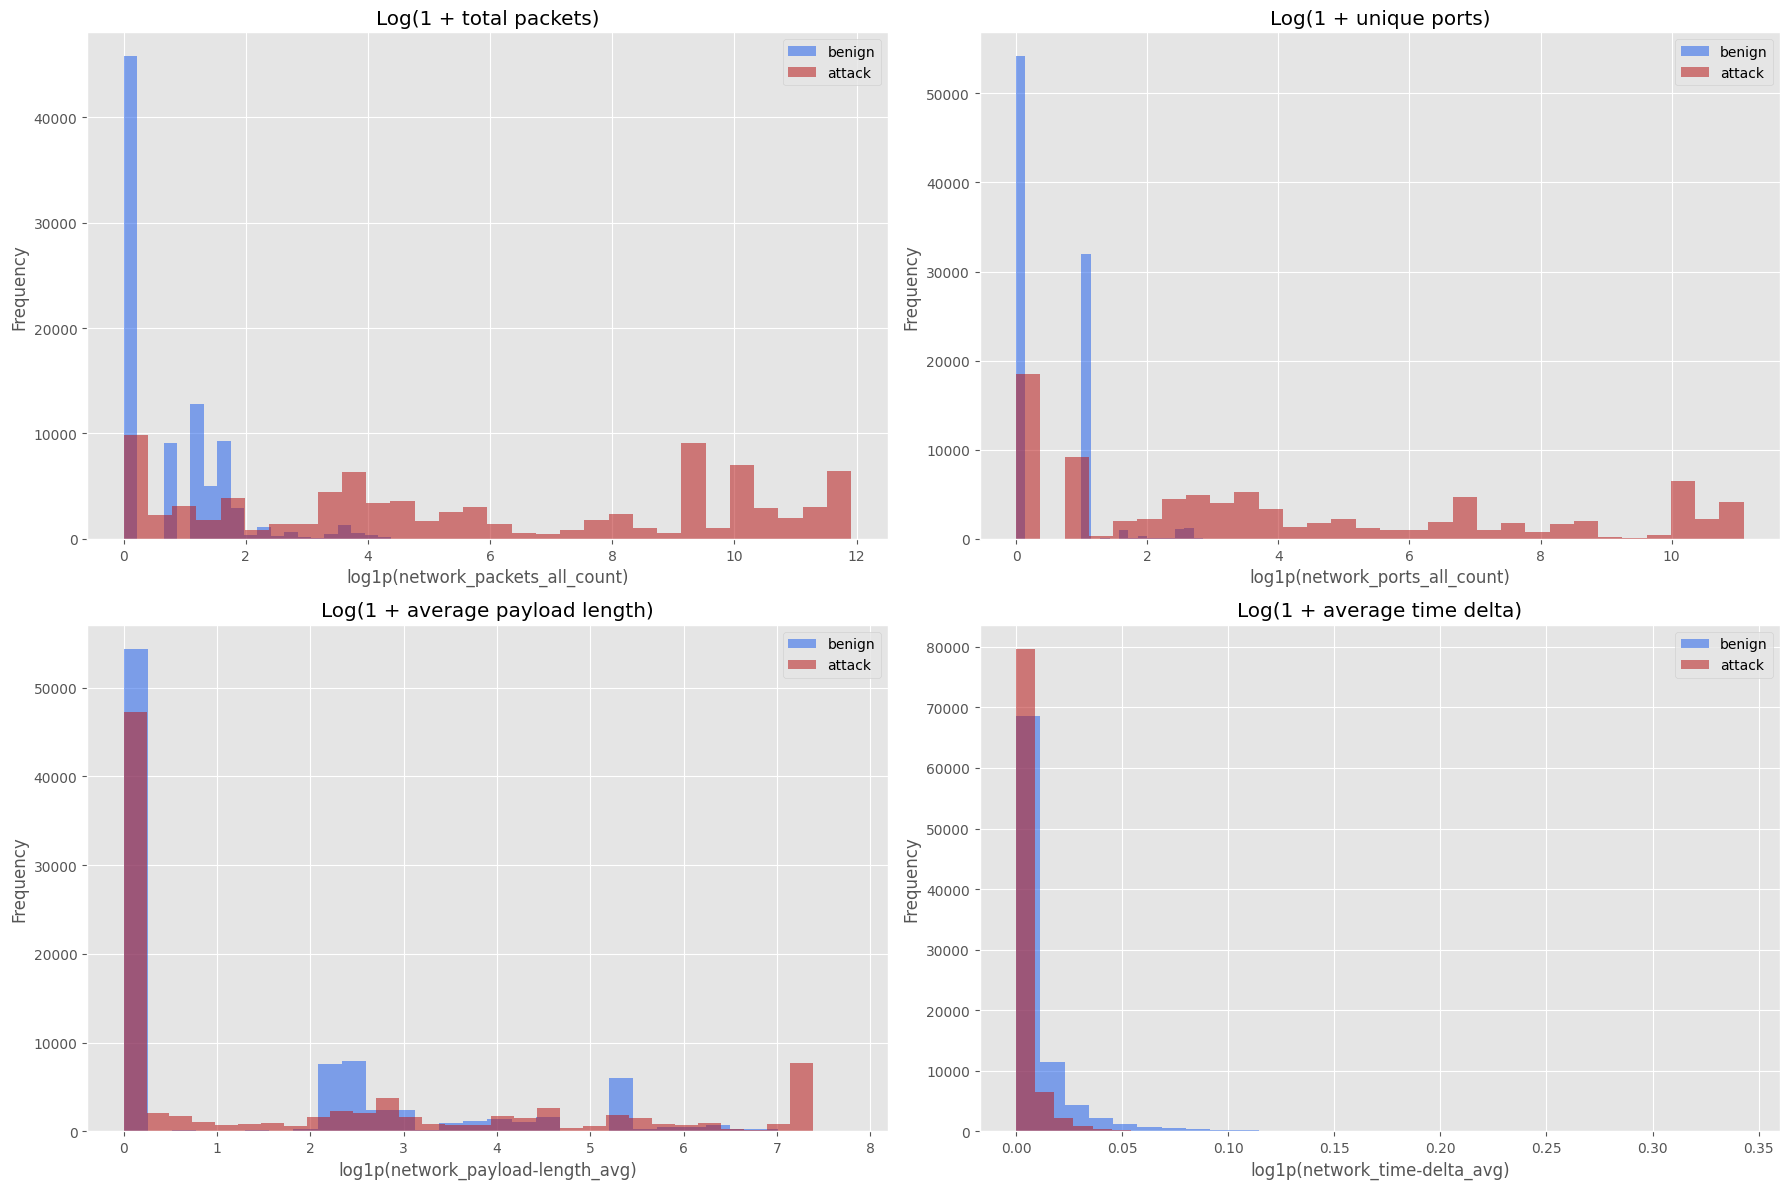

In [11]:
balanced_benign = benign_df.sample(n=len(attack_df), random_state=42)
viz_df = pd.concat([balanced_benign, attack_df], ignore_index=True)

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

for cls, color in [('benign', '#2563eb'), ('attack', '#b91c1c')]:
    subset = viz_df[viz_df['dataset_class'] == cls]
    axes[0, 0].hist(np.log1p(subset['network_packets_all_count']), bins=30, alpha=0.55, label=cls, color=color)
    axes[0, 1].hist(np.log1p(subset['network_ports_all_count']), bins=30, alpha=0.55, label=cls, color=color)
    axes[1, 0].hist(np.log1p(subset['network_payload-length_avg']), bins=30, alpha=0.55, label=cls, color=color)
    axes[1, 1].hist(np.log1p(subset['network_time-delta_avg']), bins=30, alpha=0.55, label=cls, color=color)

axes[0, 0].set_title('Log(1 + total packets)')
axes[0, 0].set_xlabel('log1p(network_packets_all_count)')
axes[0, 0].set_ylabel('Frequency')

axes[0, 1].set_title('Log(1 + unique ports)')
axes[0, 1].set_xlabel('log1p(network_ports_all_count)')
axes[0, 1].set_ylabel('Frequency')

axes[1, 0].set_title('Log(1 + average payload length)')
axes[1, 0].set_xlabel('log1p(network_payload-length_avg)')
axes[1, 0].set_ylabel('Frequency')

axes[1, 1].set_title('Log(1 + average time delta)')
axes[1, 1].set_xlabel('log1p(network_time-delta_avg)')
axes[1, 1].set_ylabel('Frequency')

for ax in axes.flatten():
    ax.legend()

plt.tight_layout()
plt.show()


### How to interpret these plots

Before interpreting the distributions, note that these histograms use the transformation `log(1 + x)`.

### Why a logarithmic transformation was applied

Many network variables have:

- many values equal to `0`,
- many small values,
- and a smaller number of very large values.

If we plotted the raw values directly, the largest values would dominate the graph and the smaller values would be hard to see. Using `log(1 + x)` compresses the very large values and makes the overall distribution easier to read.

The `1 + x` part is important because some rows have value `0`. Since `log(0)` is undefined, we use `log(1 + x)` so that a value of `0` becomes `log(1) = 0` and can still be plotted correctly.

So the logarithmic scale does **not** change which values are bigger or smaller; it simply makes the graph more readable.

- **Packets:** if attack windows sit much farther to the right, attacks are more intense than benign traffic.
- **Ports:** if attack windows show many more ports, the malicious activity may be structurally broader.
- **Payload length:** if benign traffic has richer payloads but attacks do not, then content-carrying behavior differs between the two classes.
- **Time delta:** if attack values cluster closer to zero, attack packets are arriving more rapidly and more densely in time.


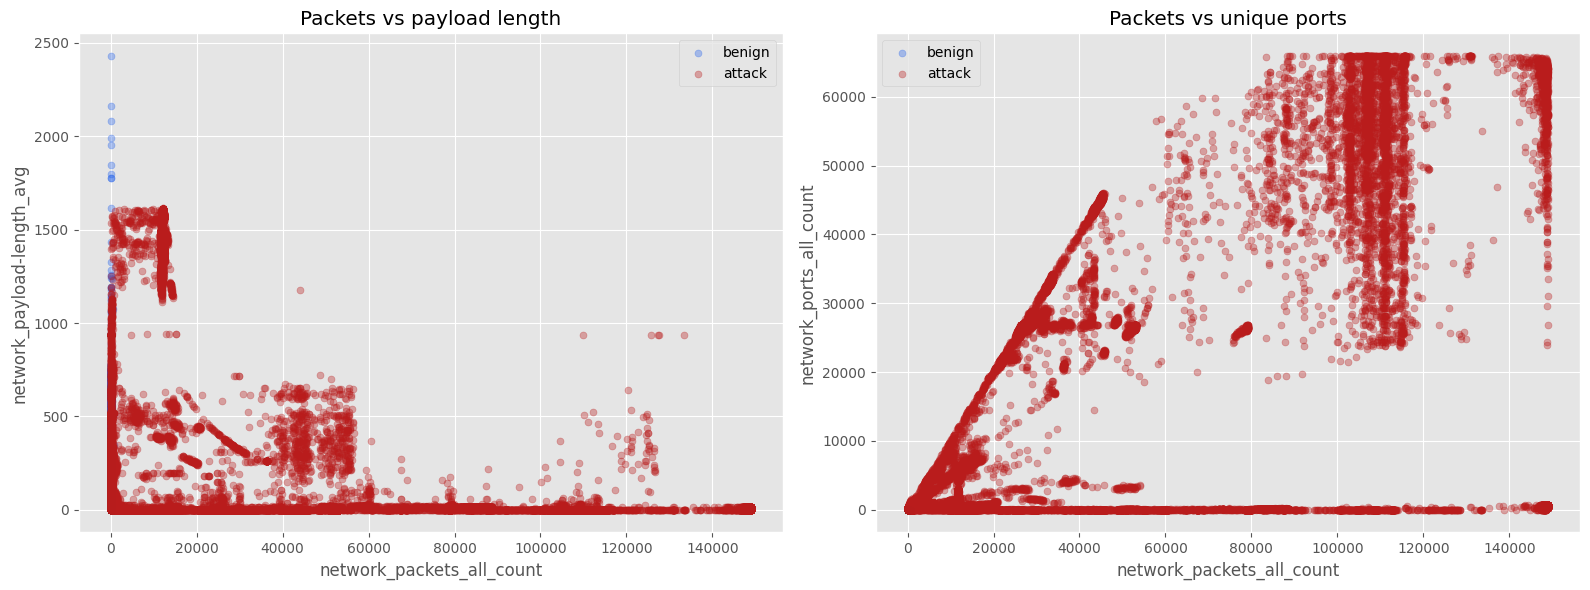

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for cls, color in [('benign', '#2563eb'), ('attack', '#b91c1c')]:
    subset = viz_df[viz_df['dataset_class'] == cls]
    axes[0].scatter(subset['network_packets_all_count'], subset['network_payload-length_avg'], alpha=0.35, s=25, label=cls, color=color)
    axes[1].scatter(subset['network_packets_all_count'], subset['network_ports_all_count'], alpha=0.35, s=25, label=cls, color=color)

axes[0].set_title('Packets vs payload length')
axes[0].set_xlabel('network_packets_all_count')
axes[0].set_ylabel('network_payload-length_avg')

axes[1].set_title('Packets vs unique ports')
axes[1].set_xlabel('network_packets_all_count')
axes[1].set_ylabel('network_ports_all_count')

for ax in axes:
    ax.legend()

plt.tight_layout()
plt.show()


### Interpretation

Scatter plots help us see relationships, not just individual distributions.

- If attack points cluster at very high packet counts with low payload, that suggests flood-like behavior.
- If attack points also show high port counts, then attacks differ not only in volume but also in communication structure.
- If benign traffic stays concentrated at lower values, then the classes are likely separable even with simple models.


## <div style="color:#1d4ed8;">8. Device-aware comparison for overlapping devices</div>

A strong analysis should not only compare classes globally. It should also ask whether the same device behaves differently under benign and attack conditions.


In [13]:
device_compare = combined_df[combined_df['device_name'].isin(overlap_devices)].groupby(['device_name', 'dataset_class']).agg(
    rows=('device_name', 'size'),
    mean_packets=('network_packets_all_count', 'mean'),
    median_packets=('network_packets_all_count', 'median'),
    mean_ports=('network_ports_all_count', 'mean'),
    mean_payload=('network_payload-length_avg', 'mean')
).reset_index()

device_compare


,device_name,dataset_class,rows,mean_packets,median_packets,mean_ports,mean_payload
0,accelerometer-sensor,attack,2568,22148.019860,399.0,7902.780374,195.227753
1,accelerometer-sensor,benign,3600,3.293333,3.0,2.001667,13.515606
2,ap,attack,3276,22290.311355,4008.0,7485.084554,198.173711
3,ap,benign,3600,0.285556,0.0,0.206111,93.177477
4,blurams-camera,attack,2431,24556.552448,6840.0,8560.503085,224.119201
5,blurams-camera,benign,3600,2.432222,0.0,0.765556,28.400991
6,dekco-camera,attack,2413,24716.383755,4295.0,8661.403232,210.326845
7,dekco-camera,benign,3600,0.445278,0.0,0.084722,5.114193
8,edge1,attack,8870,9475.902706,225.0,2895.219842,112.727098
9,edge1,benign,3600,0.994722,0.0,0.065000,0.954272


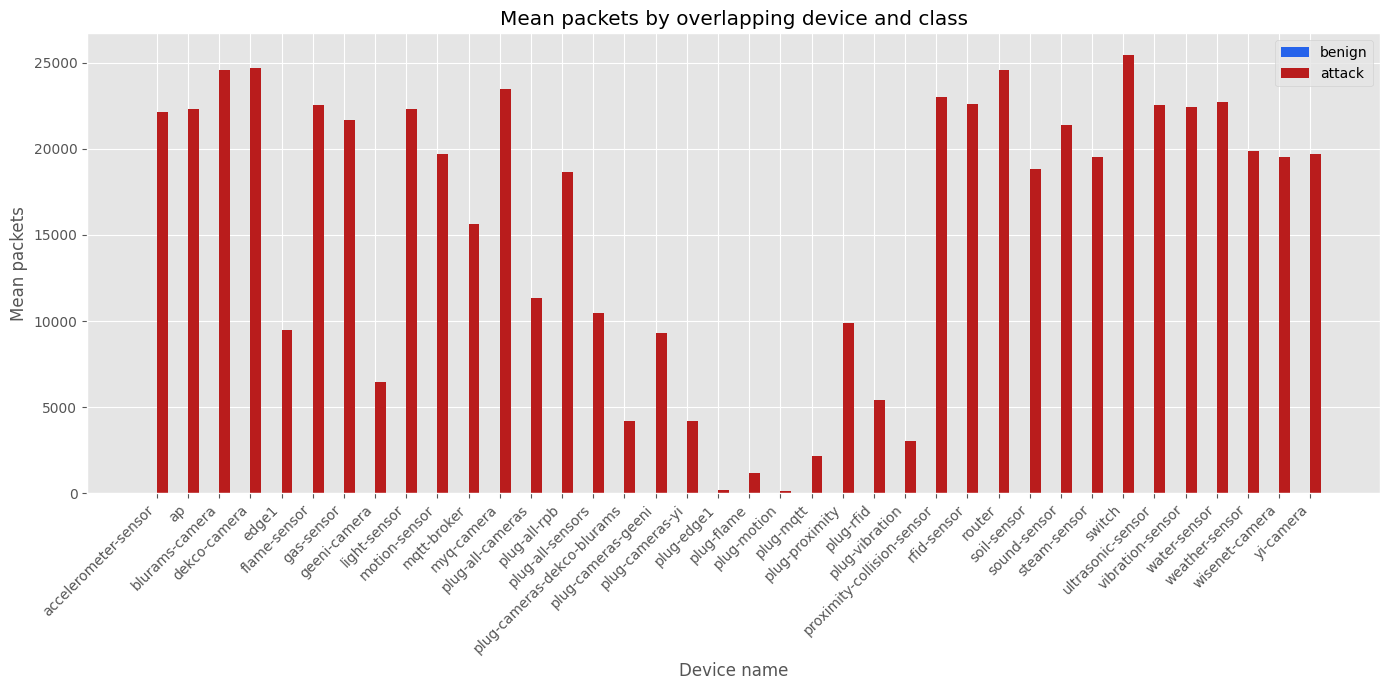

In [14]:
fig, ax = plt.subplots(figsize=(14, 7))
plot_data = device_compare.pivot(index='device_name', columns='dataset_class', values='mean_packets').fillna(0)
plot_data = plot_data.sort_index()
x = np.arange(len(plot_data.index))
width = 0.35
ax.bar(x - width/2, plot_data['benign'], width, label='benign', color='#2563eb')
ax.bar(x + width/2, plot_data['attack'], width, label='attack', color='#b91c1c')
ax.set_xticks(x)
ax.set_xticklabels(plot_data.index, rotation=45, ha='right')
ax.set_ylabel('Mean packets')
ax.set_xlabel('Device name')
ax.set_title('Mean packets by overlapping device and class')
ax.legend()
plt.tight_layout()
plt.show()


### Interpretation

This device-aware comparison is especially important for your project. If the same device shows radically different traffic under attack, then we are seeing real behavioral change rather than just dataset composition differences.

One visual detail is important here: in many cases the benign bars may look very small or almost invisible compared with the attack bars. That does not mean the benign devices have no data. It usually means their mean packet counts are much lower than the attack packet counts, so on the same vertical scale the benign bars are compressed near the bottom.

In other words, the red attack bars dominate visually because the attack traffic is much more intense for those devices, while the benign traffic remains relatively low. That itself is an important finding.

That strengthens the case that the dataset can support meaningful detection experiments.


## <div style="color:#1d4ed8;">9. What this means for classical models</div>

At this stage, the data suggests that simple non-graph models may already perform reasonably well because some attack signals are very strong.

Examples of promising baseline models for the next step:

- Logistic Regression
- Naive Bayes
- LDA
- QDA
- k-NN

However, the imbalance means evaluation must be careful. A model that predicts mostly benign could still look good under naive accuracy.


## <div style="color:#1d4ed8;">10. What this means for graph-based modeling</div>

This comparison also gives us clues about what a future graph should preserve.

Graph-relevant signals include:

- which devices communicate with which IPs,
- which ports are involved,
- which protocols are active,
- how those relationships change over time,
- and whether attack traffic produces denser, faster, or more irregular connectivity patterns.

A classical model sees each row as a flat vector. A graph model can preserve the structure behind those numbers. That is the key reason your research question is interesting.


## <div style="color:#1d4ed8;">11. Final evaluation</div>

<div style="padding: 14px 18px; background: #f8fafc; border-radius: 8px; border-left: 6px solid #0f766e;">
<b>Short answer:</b> yes, combining these two files in one notebook is the correct next step, because this is where we can finally compare benign and malicious behavior directly.
</div>

### What we learned

- The two datasets are structurally compatible.
- The attack dataset is smaller than the benign dataset, but it is now large enough to support much more credible comparison and modeling.
- The class imbalance is severe and must be handled carefully.
- Several features strongly separate benign and attack traffic, especially packet counts, ports, and TCP flags.
- The same devices appear in both datasets, which makes the comparison more meaningful.

### What this notebook does not do yet

- It does not train models yet.
- It does not rebalance the data yet.
- It does not build the graph yet.

But it does establish the evidence we need to justify those next steps.


## <div style="color:#1d4ed8;">12. Suggested next step</div>

The next notebook should be a first baseline modeling notebook. In that notebook we should:

1. select a clean set of numeric features,
2. split data into train and test sets carefully,
3. handle class imbalance,
4. train a few classical models,
5. compare their precision, recall, F1-score, and ROC-AUC,
6. then prepare the graph version of the same problem.
